In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
df = pd.read_csv("Mall_Customers.csv")
print("Dataset loaded successfully.")
print("Rows and Columns:", df.shape)
print ("\nFirst 10 Rows:")
display(df.head(10))

Dataset loaded successfully.
Rows and Columns: (200, 5)

First 10 Rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [7]:
print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()


Column names:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

Data types:
CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [8]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal duplicate rows:")
print(df.duplicated().sum())

print("\nBasic statistical summary:")
df.describe()

Missing values in each column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total duplicate rows:
0

Basic statistical summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Fill missing numerical values with median
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Data cleaning completed.")
print("New shape after cleaning:", df_clean.shape)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

Data cleaning completed.
New shape after cleaning: (200, 5)

Missing values after cleaning:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


Numerical columns used for EDA:
['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Statistical summary of useful numerical columns:


,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


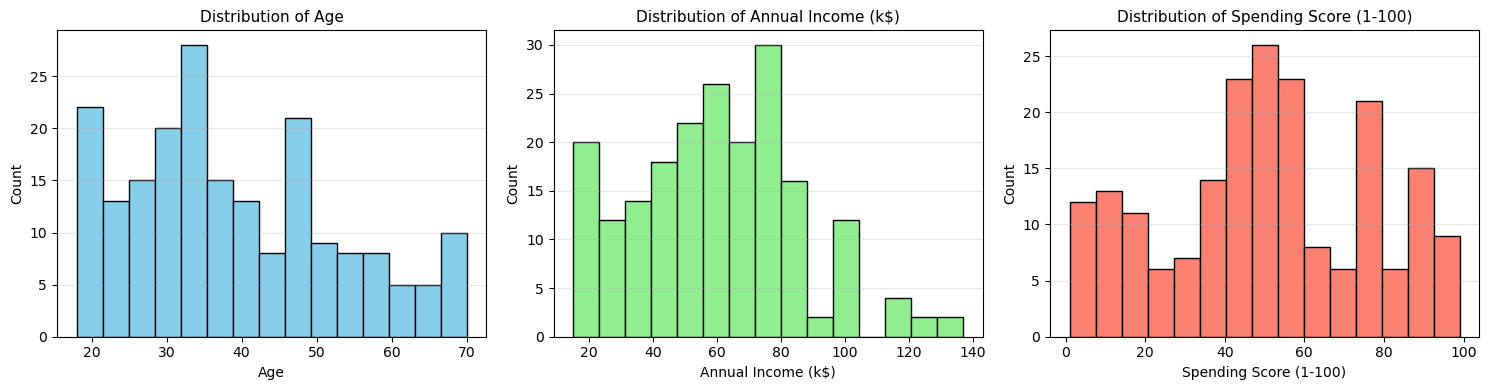

In [10]:
# Select numerical columns but remove ID/customer ID columns
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

eda_cols = [
    col for col in numeric_cols
    if "id" not in col.lower()
]

print("Numerical columns used for EDA:")
print(list(eda_cols))

print("\nStatistical summary of useful numerical columns:")
display(df_clean[eda_cols].describe())

# Colors for better visual appearance
colors = ["skyblue", "lightgreen", "salmon", "plum", "orange"]

# Show all graphs in one line
fig, axes = plt.subplots(1, len(eda_cols), figsize=(5 * len(eda_cols), 4))

for i, col in enumerate(eda_cols):
    axes[i].hist(
        df_clean[col],
        bins=15,
        color=colors[i % len(colors)],
        edgecolor="black"
    )
    axes[i].set_title(f"Distribution of {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Feature Selection and Preparation

feature_1 = "Annual Income (k$)"
feature_2 = "Spending Score (1-100)"

# Select two numerical features
X = df_clean[[feature_1, feature_2]]

# Scale the selected features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=[feature_1 + " Scaled", feature_2 + " Scaled"]
)

# Show original and prepared/scaled values together
comparison_df = pd.concat([X.head(), X_scaled_df.head().round(2)], axis=1)

print("Feature Selection and Preparation Completed")
print("Selected features:", feature_1, "and", feature_2)
print("Shape of selected feature data:", X.shape)
print("\nOriginal values vs Prepared scaled values:")

display(comparison_df)

Feature Selection and Preparation Completed
Selected features: Annual Income (k$) and Spending Score (1-100)
Shape of selected feature data: (200, 2)

Original values vs Prepared scaled values:


,Annual Income (k$),Spending Score (1-100),Annual Income (k$) Scaled,Spending Score (1-100) Scaled
0,15,39,-1.74,-0.43
1,15,81,-1.74,1.20
2,16,6,-1.70,-1.72
3,16,77,-1.70,1.04
4,17,40,-1.66,-0.40


In [12]:
# Cluster Development Using K-Means
kmeans_model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)
# Apply K-Means on prepared/scaled data
df_clean["Cluster"] = kmeans_model.fit_predict(X_scaled)
print("K-Means clustering completed successfully.")
print("Number of clusters selected: 3")

# Show cluster count table
cluster_counts = df_clean["Cluster"].value_counts().sort_index().reset_index()
cluster_counts.columns = ["Cluster", "Number of Customers"]
print("\nNumber of customers in each cluster:")
display(cluster_counts)
print("\nSample clustered data:")
display(df_clean[[feature_1, feature_2, "Cluster"]].head(10))

K-Means clustering completed successfully.
Number of clusters selected: 3

Number of customers in each cluster:


,Cluster,Number of Customers
0,0,38
1,1,39
2,2,123



Sample clustered data:


,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,2
1,15,81,2
2,16,6,2
3,16,77,2
4,17,40,2
5,17,76,2
6,18,6,2
7,18,94,2
8,19,3,2
9,19,72,2


Elbow Method completed.
Different K values tested: 1 to 10


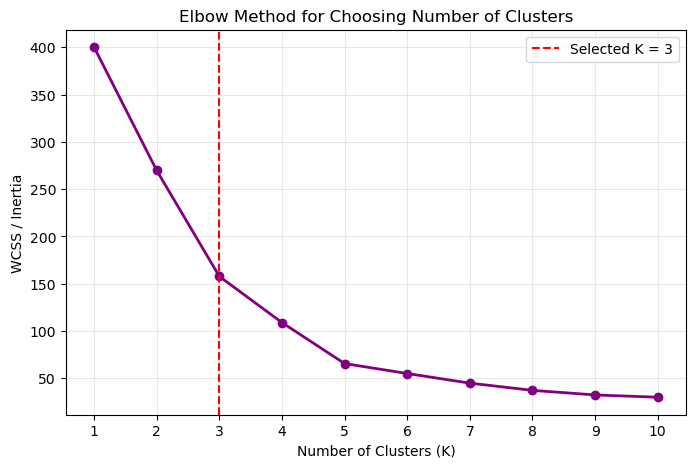

In [13]:
# Cluster Evaluation and Validation - Elbow Method

wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

print("Elbow Method completed.")
print("Different K values tested: 1 to 10")

plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker="o", color="purple", linewidth=2)
plt.axvline(x=3, color="red", linestyle="--", label="Selected K = 3")

plt.title("Elbow Method for Choosing Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.xticks(K_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

K = 2, Silhouette Score = 0.321
K = 3, Silhouette Score = 0.467
K = 4, Silhouette Score = 0.494
K = 5, Silhouette Score = 0.555
K = 6, Silhouette Score = 0.540
K = 7, Silhouette Score = 0.528
K = 8, Silhouette Score = 0.455
K = 9, Silhouette Score = 0.457
K = 10, Silhouette Score = 0.443

Final selected K = 3
Final Silhouette Score for K = 3: 0.467


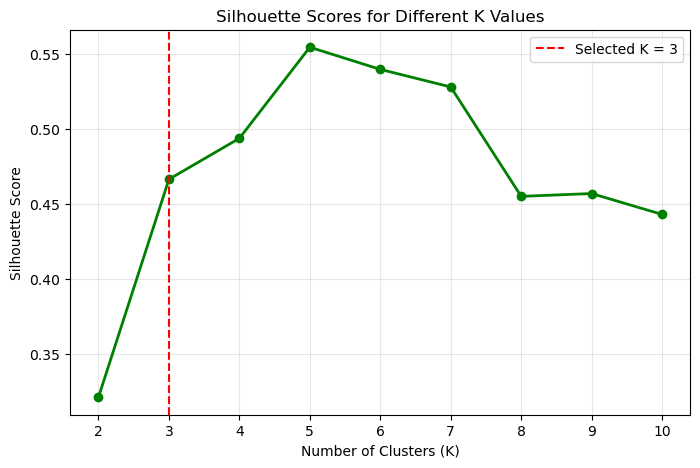

In [14]:
# Cluster Evaluation and Validation - Silhouette Score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K = {k}, Silhouette Score = {score:.3f}")

final_silhouette = silhouette_score(X_scaled, df_clean["Cluster"])

print("\nFinal selected K = 3")
print(f"Final Silhouette Score for K = 3: {final_silhouette:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker="o", color="green", linewidth=2)
plt.axvline(x=3, color="red", linestyle="--", label="Selected K = 3")

plt.title("Silhouette Scores for Different K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

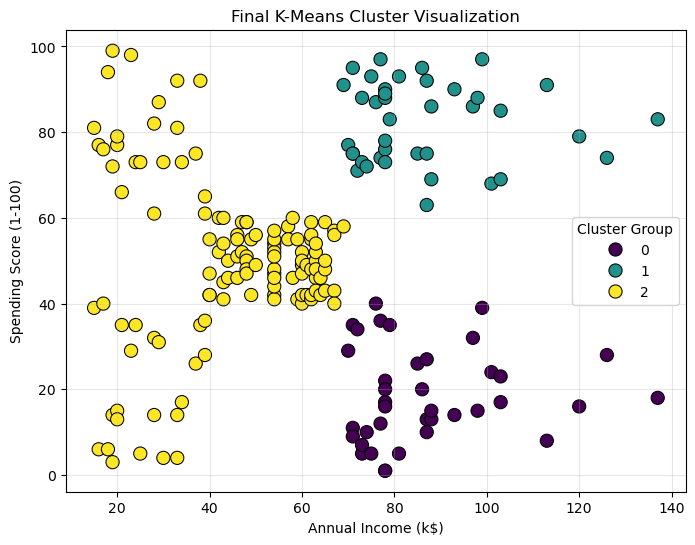

In [15]:
# Cluster Evaluation and Validation - Final Cluster Visualization

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_clean,
    x=feature_1,
    y=feature_2,
    hue="Cluster",
    palette="viridis",
    s=90,
    edgecolor="black"
)

plt.title("Final K-Means Cluster Visualization")
plt.xlabel(feature_1)
plt.ylabel(feature_2)
plt.legend(title="Cluster Group")
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# Interpretation of Clusters

cluster_summary = df_clean.groupby("Cluster")[[feature_1, feature_2]].mean().round(2)
cluster_summary["Number of Customers"] = df_clean.groupby("Cluster").size()

cluster_summary = cluster_summary.reset_index()

# Find low, moderate, high levels using the cluster averages
income_low = cluster_summary[feature_1].quantile(0.33)
income_high = cluster_summary[feature_1].quantile(0.67)

spending_low = cluster_summary[feature_2].quantile(0.33)
spending_high = cluster_summary[feature_2].quantile(0.67)

def get_level(value, low, high):
    if value <= low:
        return "Low"
    elif value >= high:
        return "High"
    else:
        return "Moderate"

def interpret_row(row):
    income_level = get_level(row[feature_1], income_low, income_high)
    spending_level = get_level(row[feature_2], spending_low, spending_high)
    return f"{income_level} Income - {spending_level} Spending"

cluster_summary["Cluster Name"] = cluster_summary.apply(interpret_row, axis=1)

def business_meaning(label):
    if label == "High Income - High Spending":
        return "Valuable customers; offer premium products and loyalty rewards."
    elif label == "High Income - Low Spending":
        return "Potential customers; use personalized offers to increase spending."
    elif label == "Low Income - High Spending":
        return "Deal-sensitive customers; offer discounts, bundles, and rewards."
    elif label == "Low Income - Low Spending":
        return "Budget customers; promote low-cost offers and basic campaigns."
    elif label == "Moderate Income - Moderate Spending":
        return "Regular customers; maintain engagement with balanced promotions."
    else:
        return "Mixed group; target with general marketing offers."

cluster_summary["Cluster Name"].apply(business_meaning)

cluster_summary = cluster_summary[
    ["Cluster", "Number of Customers", feature_1, feature_2, "Cluster Name"]
]

print("Cluster interpretation summary:")
display(cluster_summary)

Cluster interpretation summary:


,Cluster,Number of Customers,Annual Income (k$),Spending Score (1-100),Cluster Name
0,0,38,87.00,18.63,High Income - Low Spending
1,1,39,86.54,82.13,Moderate Income - High Spending
2,2,123,44.15,49.83,Low Income - Moderate Spending
